# Joint SSMT: a tutorial walkthrough

**Single-trial spike-field coupling**

This notebook is meant to be a self-contained tutorial using Joint SSMT. We will walk through the method, generate synthetic data, run inference, and interpret every output plot. By the end you would know:

- what problem Joint SSMT solves and how it compares to classical measures like SFC and PLV
- how the model is set up at a conceptual level
- what each configuration parameter controls
- how to read the coupling-detection heatmap, the spectrogram, and the posterior diagnostics
- where the model can be wrong and what to watch out for

If you already know the method and just want a short runnable example, see `quickstart_single_trial.ipynb` instead.


## 1. The problem

Across many brain areas, spike timing tends to lock to the phase of local field potential (LFP) oscillations at specific frequencies. This phenomenon is called **spike-field coupling** and it has distinctive signatures across different physiology states (e.g. anesthesia, sleep) and relfects cognitive engagements (e.g. attention). Quantifying it tells us something about how spiking is organized in time relative to the local field inputs.

The two classical measures are:

- **Phase-locking value (PLV)**: estimate the LFP phase at every spike time, then compute how concentrated those phases are on the unit circle.
- **Spike-field coherence (SFC)**: compute the spectral coherence between the spike train (converting the point process to a continous process) and the LFP signal.

Both follow the same procedure: estimate the LFP spectrum first, then plug in the coupling strength estimates based on the point estimation of the LFP spectrum. Two things follow from this.

1. **Uncertainty in the spectrogram does not propagate.** If the LFP spectral estimate is noisy or wrong, the coupling estimate inherits that error without a principled way to reflect our uncertainty. 
2. **Spike timing does not feed back into the spectrogram.** Spike timing carries information about the underlying oscillation, so ignoring it leaves out information for LFP spectorgram estimation. 

Joint SSMT is a **Bayesian state-space model** that treats the LFP spectrogram and the spike-field coupling as a single estimation problem. The spectrogram is treated as a latent process. The LFP is a noisy observation of that latent. The spike train is also a (different kind of) observation of the same latent. The coupling coefficient is a regression parameter that we infer alongside the spectrogram, with full uncertainty quantification.


## 2. The model (intuition)

You can read the paper for the math. Here is the intuition.

**A latent spectrogram.** Traditional spectrogram estimation across time window often treat the sliding time window as indepdent observations. Real data often have temporal structures that endow the process with some smoothness and we can leverage this fact to regularize our estimation. 
For each frequency $\omega_j$ on the analysis grid, we model the complex Fourier coefficient as a continuous-time stochastic process (an Ornstein-Uhlenbeck diffusion). This means the amplitude and phase at frequency $\omega_j$ drift smoothly over time rather than being independent in each time window. The smoothness is controlled by a per-frequency mean-reversion rate $\lambda_j$ that we learn from data.

**Two ways to observe the latent.** We have two data streams that look at the same latent process.

- The **multitaper LFP coefficients** at coarse time blocks (typically every 1-2 seconds). These are direct, Gaussian observations of the latent at block centers.
- The **spike train** at fine time resolution (every few milliseconds). At each fine time bin, the probability of a spike is a logistic function of the instantaneous spectral coefficients, plus a baseline and a spike-history term.

**Joint inference.** Because both streams observe the same latent, fusing them sharpens the estimate of the latent and propagates uncertainty into the coupling estimate. The technical step that makes this tractable is **Pólya-Gamma augmentation**, which turns the Bernoulli spike likelihood into a conditionally Gaussian observation, allowing standard Kalman smoothing.

**What you get.**

- A posterior over the spectrogram at each frequency, with credible intervals.
- A posterior over the complex coupling coefficient $\beta_C = \beta_R + i \beta_I$ for each (unit, frequency) pair.
- A Wald test statistic and p-value for whether $\beta_C$ is significantly different from zero.


## 3. Setup

If the package is not installed yet, uncomment the install line below.

In [ ]:
!pip install -e ..


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from joint_ssmt import (
    simulate_single_trial,
    SingleTrialSimConfig,
)
from joint_ssmt.io import run_inference, load_results


/Users/bowenzheng-millerlab/joint-ssmt/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Simulate synthetic data

We generate data with **known** ground-truth coupling so that we can validate the inference at the end.

The simulator produces:

- An LFP signal containing oscillatory components at five frequencies (4, 8, 12 Hz are couplable, plus 7 and 16 Hz that appear in the LFP but do not drive any spiking).
- Spike trains for `S` (number of units) units. Each unit is randomly assigned to couple to `k_active` of the three couplable bands, with a coupling magnitude and preferred phase drawn from configured ranges.

For real data you would skip this block and load your own LFP (1-D array of shape `(T,)`) and spike trains (2-D array of shape `(S, T_fine)` of binary spike indicators).


In [ ]:
cfg = SingleTrialSimConfig(
    duration_sec=60.0,
    S=3,
    k_active=2,                                          # each unit couples to 2 of 3 couplable bands
    b0_mu=-3.0,
    freqs_hz=np.array([4.0, 8.0, 12.0]),                 # couplable bands
    freqs_hz_extra=np.array([7.0, 16.0]),                # signal bands that never couple
)

sim = simulate_single_trial(cfg, seed=42)

lfp    = sim['LFP']
spikes = sim['spikes']

print(f"LFP shape:    {lfp.shape}   (T = {lfp.shape[0]} samples at {cfg.fs} Hz)")
print(f"Spikes shape: {spikes.shape}")
print(f"Spike rates:  {spikes.mean(axis=1) * cfg.fs} Hz per unit")

Single-trial simulation setup:
  Units: S=3
  Coupled signal bands (Jc=3): [ 4.  8. 12.]
  Extra uncoupled signal bands (Ju=2): [ 7. 16.]
  Total signal bands (J=5): [ 4.  8. 12.  7. 16.]
  LFP: T=60000 samples at fs=1000.0 Hz
  Spikes: T_fine=60000 samples at 1000.0 Hz
Generating OU latent processes...
Computing derotated latents for spike predictors...
Generating coupling parameters...
  beta_true shape: (3, 11) (SEPARATED layout)
Generating spikes...
  Spikes per unit: [2401 2033 2422]
  Mean firing rate: 38.09 Hz
  Unit 0 firing rate: 40.02 Hz
  Unit 1 firing rate: 33.88 Hz
  Unit 2 firing rate: 40.37 Hz
Generating LFP with broadband noise...
Simulation complete.
LFP shape:    (60000,)   (T = 60000 samples at 1000.0 Hz)
Spikes shape: (3, 60000)
Spike rates:  [40.01666667 33.88333333 40.36666667] Hz per unit


### 4a. What does the data look like?

Before running anything, it is worth visualizing the raw inputs. The LFP looks noisy in the time domain. 


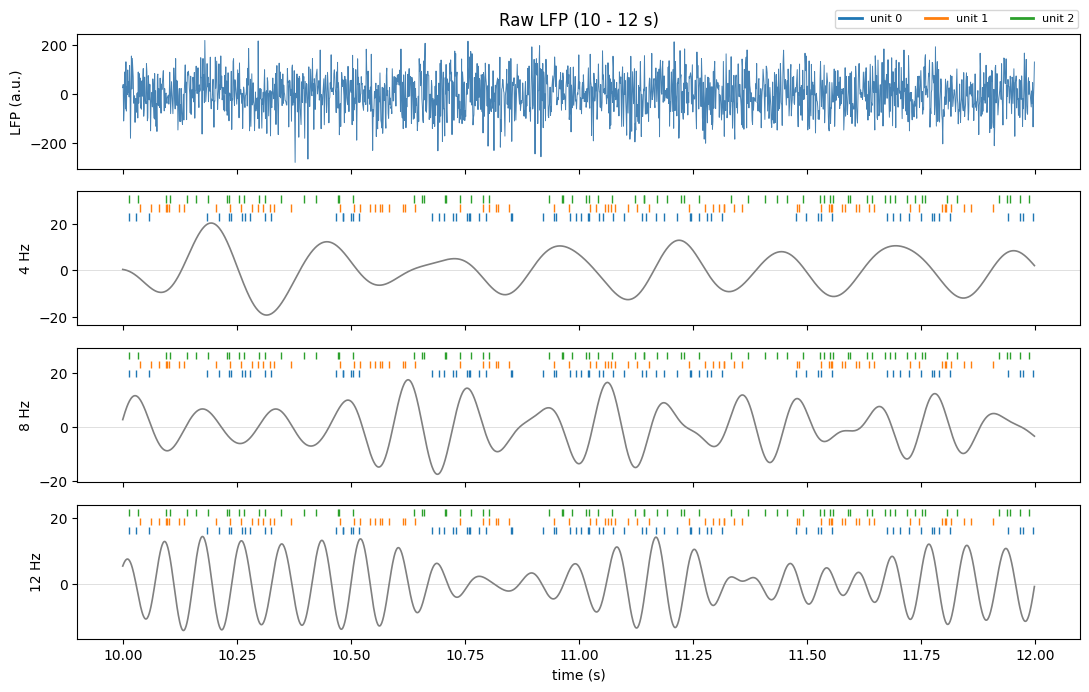

In [25]:
from scipy.signal import butter, filtfilt

window_sec = 2
offset_sec = 10  # Offset start time by 10 seconds

n_lfp = int(window_sec * cfg.fs)
start_idx = int(offset_sec * cfg.fs)
end_idx = start_idx + n_lfp
t_lfp = np.arange(n_lfp) / cfg.fs + offset_sec  # Offset the time axis by 10 seconds

def bandpass(signal, fs, low, high, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, signal)

band_centers = [4, 8, 12]      # Hz
band_halfwidth = 2

spike_times_per_unit = [
    np.where(spikes[s, start_idx:end_idx])[0] / cfg.fs + offset_sec
    for s in range(spikes.shape[0])
]
unit_colors = [f'C{s}' for s in range(spikes.shape[0])]

fig, axes = plt.subplots(len(band_centers) + 1, 1,
                         figsize=(11, 7), sharex=True)

# Raw LFP
axes[0].plot(t_lfp, lfp[start_idx:end_idx], color='steelblue', lw=0.7)
axes[0].set_ylabel('LFP (a.u.)')
axes[0].set_title(f'Raw LFP ({offset_sec} - {offset_sec+window_sec} s)')

# Band-filtered components with spike overlays
for i, fc in enumerate(band_centers):
    ax = axes[i + 1]
    filtered = bandpass(lfp, cfg.fs, fc - band_halfwidth, fc + band_halfwidth)
    ax.plot(t_lfp, filtered[start_idx:end_idx], color='gray', lw=1.2)
    ymax = np.max(np.abs(filtered[start_idx:end_idx])) * 1.05

    # Stack colored spike ticks above the signal, one row per unit
    tick_h = ymax * 0.18
    for s, st in enumerate(spike_times_per_unit):
        y0 = ymax + tick_h * s
        y1 = ymax + tick_h * (s + 1) - tick_h * 0.15
        ax.vlines(st, y0, y1, color=unit_colors[s], lw=1.0)

    ax.axhline(0, color='lightgray', lw=0.5, zorder=0)
    ax.set_ylim(-ymax * 1.1, ymax + tick_h * len(spike_times_per_unit) * 1.1)
    ax.set_ylabel(f'{fc} Hz')

axes[-1].set_xlabel('time (s)')

handles = [plt.Line2D([0], [0], color=c, lw=2) for c in unit_colors]
labels = [f'unit {s}' for s in range(spikes.shape[0])]
fig.legend(handles, labels, loc='upper right', fontsize=8,
           bbox_to_anchor=(0.99, 0.99), ncol=len(unit_colors))

plt.tight_layout()
plt.show()

We can roughly see some patterns here: spikes tend to occur at particular phase of the filtered signal. Below we show the groundtruth coupling. 

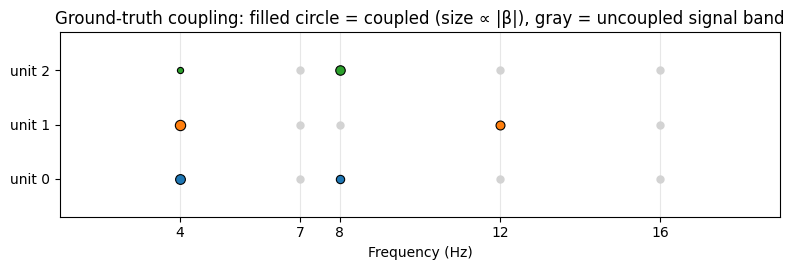

In [26]:
# Ground-truth coupling: which unit is coupled to which frequency band.
gt_freqs = sim['freqs_hz']     # all signal band frequencies
gt_mag   = sim['beta_mag']     # (S, J_true) ground truth magnitudes
masks    = sim['masks']        # (S, J_true) binary coupling mask
S        = spikes.shape[0]

fig, ax = plt.subplots(figsize=(8, 2.8))

for s in range(S):
    for j, f in enumerate(gt_freqs):
        if masks[s, j]:
            ax.scatter(f, s, s=400 * gt_mag[s, j],
                       color=unit_colors[s], edgecolor='black',
                       linewidth=0.8, zorder=3)
        else:
            ax.scatter(f, s, s=25, color='lightgray', zorder=2)

ax.set_yticks(np.arange(S))
ax.set_yticklabels([f'unit {s}' for s in range(S)])
ax.set_xlabel('Frequency (Hz)')
ax.set_xticks(gt_freqs)
ax.set_xlim(min(gt_freqs) - 3, max(gt_freqs) + 3)
ax.set_ylim(-0.7, S - 0.3)
ax.set_title('Ground-truth coupling: filled circle = coupled (size ∝ |β|), gray = uncoupled signal band')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



## 5. Run inference

The simple and flexible way to run Joint SSMT is the high-level `run_inference()` function. It takes the LFP, the spikes, and three configuration dictionaries, runs the full pipeline (CT-SSMT spectrogram + Pólya-Gamma augmented joint inference + Wald test), and writes everything to disk.

### 5a. The configuration parameters and what they mean

**Spectral configuration** controls the multitaper analysis of the LFP.

| field | meaning | default-ish |
|-------|---------|-------------|
| `freq_min`, `freq_max` | the analysis frequency band in Hz | 1, 61 |
| `freq_step` | spacing between frequency bins | 1 Hz |
| `window_sec` | length of each multitaper window in seconds | 1-2 s |
| `time_bandwidth` | controls spectral resolution and number of tapers | 2 |

The window length deserves some consideration because it has a trade-off between frequency and temporal resolution. Short windows resolve fast spectral changes but smear in frequency. Long windows resolve frequencies finely but blur in time. For LFP oscillations in the 1-60 Hz range, 1-2 s windows are usually a reasonable starting point.

**Inference configuration** controls the MCMC.

| field | meaning |
|-------|---------|
| `warmup_iterations` | initial samples to discard |
| `n_refresh_cycles` | number of times the EM refresh is run |
| `iterations_per_refresh` | post-warmup samples between refreshes |

For development, 200 warmup + 2 refresh cycles is fast and usually fine. For real analyses, push warmup to 500-1000 and increase the refresh cycles.

**Output configuration** controls what gets saved.

| field | meaning |
|-------|---------|
| `output_dir` | directory for results |
| `save_spectral` | save full spectral state (needed for the spectrogram and dynamics plots) |


### Sidebar: the higher-level `run_auto_inference()`

For a one-call **data-in / figures-out** workflow, use `run_auto_inference()` from `joint_ssmt`. It wraps `run_inference()` (or `run_inference_trials()` for trial-structured data), validates the input shapes, prints a pre-flight summary, asks for a single confirmation, and writes the inference results and default plots into a single output directory. See `examples/auto_inference_demo.ipynb`.

The rest of this tutorial uses the lower-level `run_inference()` so you can see what each config does.

In [27]:
saved = run_inference(
    lfp=lfp,
    spikes=spikes,
    spectral_config={
        'freq_min': 1.0,
        'freq_max': 61.0,
        'freq_step': 1.0,
        'window_sec': 2.0,
        'time_bandwidth': 2.0,
    },
    inference_config={
        'warmup_iterations': 300,
        'n_refresh_cycles': 2,
        'iterations_per_refresh': 100,
    },
    output_config={
        'output_dir': './results_single',
        'save_spectral': True,
    },
    fs=cfg.fs,
    plot=False,   # we will draw plots manually below
)

print("Saved files:")
for f in saved:
    print(f"  {f}")


[EM-CT-JAX] iter    0  Q = -3.5610e+04
[EM-CT-JAX] Unfreezing lambda at iter 50
[EM-CT-JAX] Converged at iter 50  Q = -2.6691e+04


Refresh 1 inner PG steps:   0%|          | 0/100 [00:00<?, ?it/s]/Users/bowenzheng-millerlab/joint-ssmt/.venv/lib/python3.11/site-packages/jax/_src/scipy/linalg.py:167: FutureWarning: jax.scipy.linalg.cho_solve: batched 1D solves with b.ndim > 1 are deprecated, and in the future will be treated as a batched 2D solve. Use cho_solve(c_and_lower, b[..., None]).squeeze(-1) to avoid this warning.
  warnings.warn(


Saved files:
  coupling
  spectral
  metadata


### 5b. What is happening under the hood

For each frequency $\omega_j$ on the grid, the inference loop alternates three blocks (Algorithm 1 of the paper).

1. **Pólya-Gamma block.** For each spike bin, draw the auxiliary variable $\xi_n \sim \mathrm{PG}(1, |\psi_n|)$. Conditional on $\xi$, the Bernoulli spike likelihood becomes Gaussian.
2. **Regression block.** Given the current latent trajectory and the auxiliary variables, draw the coupling coefficients $\beta = (\beta_0, \beta_R, \beta_I, \gamma_1, \ldots, \gamma_H)$ from a Gaussian conditional posterior.
3. **Latent-state block.** Run a Kalman filter and an RTS smoother on the spike-bin grid, fusing LFP observations at block centers and spike pseudo-observations at every fine bin.

Periodically, an EM step updates the per-frequency $\lambda_j$ and the OU diffusion variance $\sigma_{v,j}^2$ from the smoothed sufficient statistics.

You do not need to interact with these blocks directly. The high-level `run_inference()` should handel them for you. If you ever want to swap pieces in or out (for instance, to use a different prior on $\beta$), the lower-level functions are exposed in `joint_ssmt.run_joint_inference_single_trial`.


## 6. Load and inspect the results

Results are written as `.npz` arrays plus a `metadata.json`. `load_results()` returns a nested dict.


In [28]:
results = load_results('./results_single')

# Top-level keys
print("Top-level keys:", list(results.keys()))

coupling = results['coupling']
print("\nCoupling sub-keys:", list(coupling.keys()))

freqs    = coupling['freqs']       # (J,)
beta_mag = coupling['beta_mag']    # (S, J) posterior mean magnitude

S, J = beta_mag.shape
print(f"\nFrequency grid: {J} bands from {freqs[0]:.0f} to {freqs[-1]:.0f} Hz")
print(f"Units:          {S}")


Top-level keys: ['coupling', 'spectral', 'metadata']

Coupling sub-keys: ['beta', 'gamma', 'freqs', 'beta_mag', 'beta_phase', 'beta_trace', 'gamma_trace', 'beta_std', 'wald_W', 'wald_pval', 'wald_significant', 'phase_R', 'phase_pval', 'phase_est', 'beta_standardized', 'latent_scale_factors', 'shrinkage_factors', 'theta_lam', 'theta_sig_v', 'theta_sig_eps']

Frequency grid: 60 bands from 1 to 60 Hz
Units:          3


## 7. The spectrogram with credible intervals

The Joint SSMT model also produces a posterior over the LFP spectrogram. This is useful in its own right, even on data where you do not care about coupling.

There are two estimates worth comparing:

- The **raw multitaper spectrogram** is the standard non-parametric estimate of LFP power. It is fast but noisy.
- The **joint spectrogram** is the smoothed posterior of the latent OU process, refined by spike timing where there is coupling.

The joint estimate is most different from the multitaper estimate at frequencies where coupling is strong, since spike timing carries information about the latent at those frequencies.


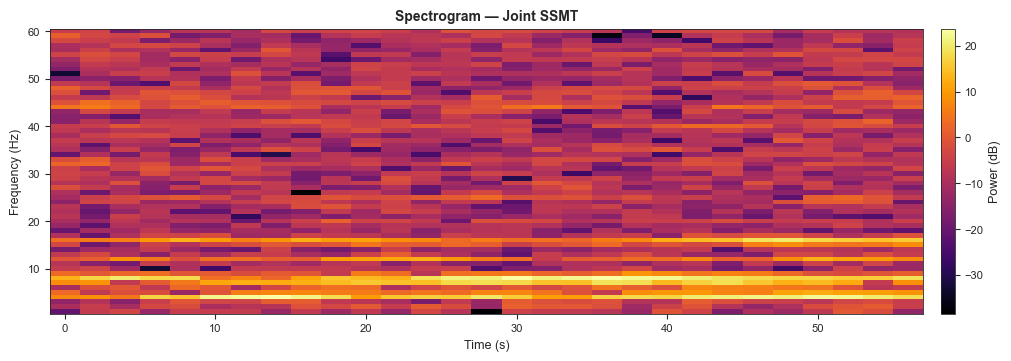

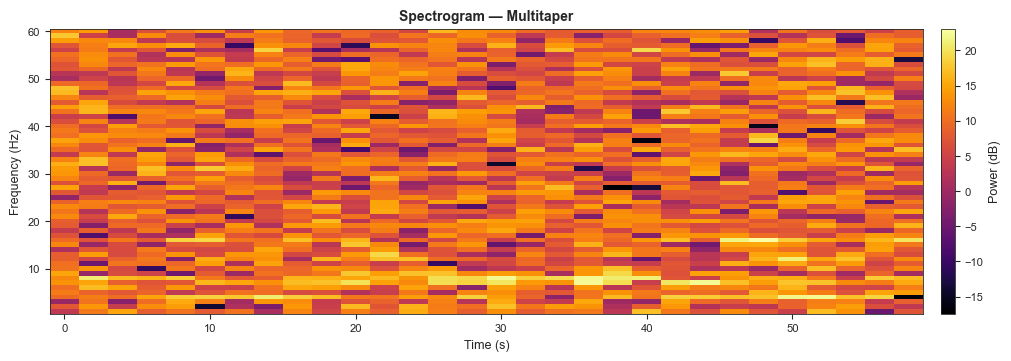

In [31]:
from joint_ssmt.plotting.summary import plot_spectrogram

# Joint model spectrogram (refined by spike information)
fig = plot_spectrogram(results, method='joint', figsize=(10, 3.5))
plt.show()

# Raw multitaper spectrogram (LFP only) for comparison
fig = plot_spectrogram(results, method='multitaper', figsize=(10, 3.5))
plt.show()


The Joint SSMT model also returns a posterior **variance** at each (frequency, time), so we can put 95% credible bands on the spectral amplitude. Plotting $|Z(t)|$ with credible bands at a handful of frequencies makes the uncertainty explicit. Frequencies where spike timing carries information about the LFP tend to have tighter credible bands, since the spike likelihood sharpens the posterior on the latent state. This visual works on real data without any ground truth.

In [ ]:
# Spectral amplitude with 95% credible bands at a few frequencies.
spectral = results['spectral']
Z_mean = spectral['Z_smooth_joint']    # (J, K) complex posterior mean
Z_var  = spectral['Z_var_joint']        # (J, K) variance
window_sec = results['metadata']['ctssmt']['window_sec']
t_blocks = np.arange(Z_mean.shape[1]) * window_sec

# Pick a few representative frequencies from the analysis grid
freqs_to_show = np.array([4.0, 7.0, 8.0, 12.0])
idx_show = [int(np.argmin(np.abs(freqs - f))) for f in freqs_to_show]

fig, ax = plt.subplots(figsize=(10, 4))
for j, f in zip(idx_show, freqs_to_show):
    amp = np.abs(Z_mean[j])
    se  = np.sqrt(Z_var[j] / 2.0)            # std of |Z| (rough Gaussian approx.)
    line, = ax.plot(t_blocks, amp, lw=1.2, label=f'{f:g} Hz')
    ax.fill_between(t_blocks, amp - 1.96 * se, amp + 1.96 * se,
                    alpha=0.2, color=line.get_color())
ax.set_xlabel('time (s)')
ax.set_ylabel(r'$|Z(t)|$ (amplitude)')
ax.set_title('Posterior amplitude with 95% credible bands')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. The main result: coupling detection

This is the key figure for most users. We test, for each (unit, frequency) pair, whether the complex coupling coefficient $\beta_C = \beta_R + i\beta_I$ is significantly different from zero. The Wald statistic is

$$W = \hat\beta^\top V_\beta^{-1} \hat\beta,$$

which is asymptotically $\chi^2$ with 2 degrees of freedom under the null $\beta_C = 0$.


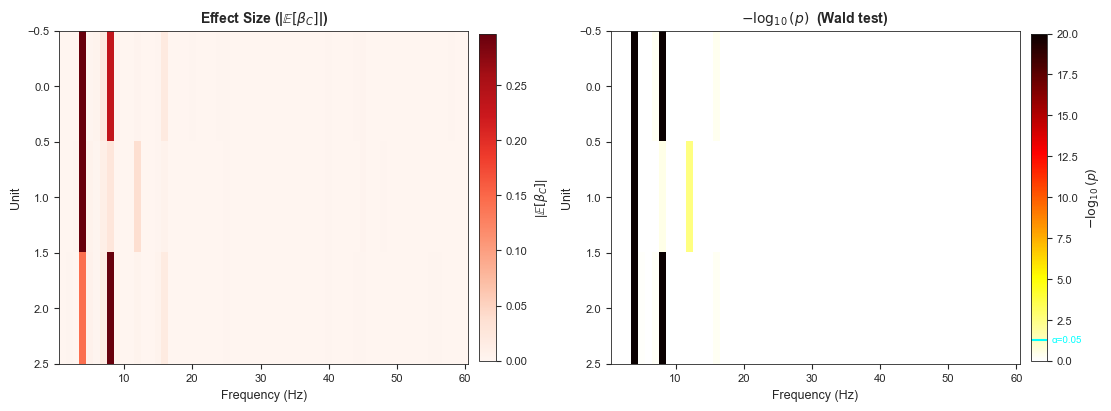

In [29]:
from joint_ssmt.plotting.heatmaps import (
    set_publication_style,
    plot_effect_comparison,
    plot_pval_comparison,
)

set_publication_style()

# Effect size: Wald W (test statistic). We deliberately do not show |β| here
# because the model's absolute coupling magnitude is not identified from the
# data alone, and is therefore not a reliable summary on its own.
plot_effect_comparison(
    {'Wald W': coupling['wald_W']},
    freqs, None,
    log_scale_keys=('Wald W',),
    suptitle='Effect size (Wald W)',
)
plt.show()

# Wald p-value
plot_pval_comparison(
    {'Wald': coupling['wald_pval']},
    freqs, None,
    alpha=0.05, suptitle='P-value (Wald)',
)
plt.show()


### 8a. How to read the heatmap

The first figure shows the Wald statistic $W$ per (unit, frequency) pair on a log scale. Larger values mean stronger evidence of coupling. The second figure shows $-\log_{10}(p)$ from the Wald test, with the cyan threshold at $\alpha = 0.05$. We do not plot $|\beta|$ here on purpose: the model recovers preferred phase reliably, but the absolute coupling magnitude is sensitive to a normalization that is not identified from the data alone. The Wald statistic is more honest because it weights the magnitude by its posterior precision.

A few things to look for.

- **Sharpness across frequency.** A truly coupled (unit, frequency) pair shows up as a single cell or a tight cluster, not a smear. Smearing usually indicates spectral leakage from a strong nearby band, or a too-short multitaper window.
- **Multiple comparisons.** With $S \times J$ cells, the nominal $\alpha = 0.05$ threshold will let in some false positives. For analyses with many cells, apply an FDR or Bonferroni correction.


### 8b. List the significant pairs

Read off the significant (unit, frequency) pairs.

In [30]:
wald_pval = coupling['wald_pval']   # (S, J)
wald_W    = coupling['wald_W']      # (S, J)
alpha = 0.05

print(f"Significant coupling pairs (alpha = {alpha}):\n")
print(f"  {'Unit':>4}  {'Freq (Hz)':>10}  {'|beta|':>8}  {'Wald W':>8}  {'p-value':>10}")
print("  " + "-" * 50)

for s in range(S):
    for j in range(J):
        if wald_pval[s, j] < alpha:
            print(f"  {s:>4}  {freqs[j]:>10.0f}  {beta_mag[s, j]:>8.4f}  "
                  f"{wald_W[s, j]:>8.2f}  {wald_pval[s, j]:>10.2e}")


Significant coupling pairs (alpha = 0.05):

  Unit   Freq (Hz)    |beta|    Wald W     p-value
  --------------------------------------------------
     0           4    0.2964    148.88    0.00e+00
     0           8    0.2316    109.43    0.00e+00
     1           4    0.2973    137.57    0.00e+00
     1          12    0.0373     11.59    3.04e-03
     2           4    0.1427     98.91    0.00e+00
     2           8    0.3115    156.29    0.00e+00


### 8c. β posterior scatter and phase distribution

The heatmap shows whether each (unit, frequency) pair is significantly coupled. To see what the model actually believes about the coupling, look at the posterior samples directly. The scatter shows samples of $\beta = \beta_R + i\beta_I$ in the complex plane (so distance from the origin is magnitude, angle is preferred phase). The polar plot shows the same samples, but in a way that emphasizes the phase distribution.

In [ ]:
from joint_ssmt.plotting.beta_posterior import plot_beta_posterior_scatter

# β posterior scatter in the complex plane, one panel per (unit, frequency).
# No ground truth: the function picks the top and bottom frequencies by Wald p-value.
for s in range(S):
    plot_beta_posterior_scatter(
        coupling['beta_trace'], freqs, None,
        unit_idx=s, burn_in_frac=0.7,
    )
    plt.suptitle(f'β posterior, unit {s}')
    plt.show()


In [ ]:
# Polar view of the posterior phase distribution at significant frequencies.
beta_trace = coupling['beta_trace']
J_grid = len(freqs)
burn = int(0.7 * beta_trace.shape[0])
bR = beta_trace[burn:, :, 1:1+J_grid]
bI = beta_trace[burn:, :, 1+J_grid:1+2*J_grid]
phase_samples = np.arctan2(bI, bR)
mag_samples = np.sqrt(bR**2 + bI**2)

rng = np.random.default_rng(0)
n_show = min(400, phase_samples.shape[0])
idx = rng.choice(phase_samples.shape[0], n_show, replace=False)

fig, axes = plt.subplots(1, S, figsize=(4.2 * S, 4.2),
                         subplot_kw={'projection': 'polar'})
if S == 1:
    axes = [axes]

for s in range(S):
    ax = axes[s]
    sig = wald_pval[s] < 0.05
    for j in np.where(sig)[0]:
        ax.scatter(phase_samples[idx, s, j], mag_samples[idx, s, j],
                   alpha=0.2, s=8, label=f'{freqs[j]:.0f} Hz')
    ax.set_title(f'unit {s}', y=1.08)
    if s == S - 1 and sig.any():
        ax.legend(bbox_to_anchor=(1.25, 1), fontsize=7, loc='upper left',
                  title='sig. freqs')

plt.suptitle('Posterior phase distribution (radius = |β|)', y=1.02)
plt.tight_layout()
plt.show()


## 9. Metadata

`metadata.json` records the configs, the timing, and the detection counts. This could help you navigate parameter choices before scaling up your analysis. 


In [32]:
meta = results['metadata']
print(f"Elapsed time:      {meta['timing']['elapsed_seconds']:.1f} s")
print(f"MCMC samples:      {meta['mcmc']['n_samples']}")
print(f"Significant bands: {meta['detection']['n_significant_bands']}")
print(f"Frequency grid:    {meta['ctssmt']['n_freqs']} bands")


Elapsed time:      299.0 s
MCMC samples:      250
Significant bands: 3
Frequency grid:    60 bands


## 10. Validation against ground truth (simulation only)

For real data this section does not apply. For simulated data, we can directly check whether the inferred preferred phase matches the simulated phase. We focus on phase here because the model recovers preferred phase reliably, while the absolute magnitude depends on a normalization that is not identified from the data alone.

The polar plot below overlays:

- **Inferred** posterior samples of $\beta$ at each significant frequency, color-coded by frequency.
- **True** simulated $(\varphi_\beta, |\beta|)$ at coupled bands, marked with a black ★.

A successful run shows the posterior cloud at each significant frequency centered near the corresponding ★.


In [ ]:
# Polar phase distribution, with ground-truth markers (★) overlaid.
gt_mag    = sim['beta_mag']
gt_phase  = sim['beta_phase']
gt_freqs  = sim['freqs_hz']
masks     = sim['masks']

beta_trace = coupling['beta_trace']
J_grid = len(freqs)
burn = int(0.7 * beta_trace.shape[0])
bR = beta_trace[burn:, :, 1:1+J_grid]
bI = beta_trace[burn:, :, 1+J_grid:1+2*J_grid]
phase_samples = np.arctan2(bI, bR)
mag_samples = np.sqrt(bR**2 + bI**2)

rng = np.random.default_rng(0)
n_show = min(400, phase_samples.shape[0])
idx = rng.choice(phase_samples.shape[0], n_show, replace=False)

fig, axes = plt.subplots(1, S, figsize=(4.2 * S, 4.2),
                         subplot_kw={'projection': 'polar'})
if S == 1:
    axes = [axes]

for s in range(S):
    ax = axes[s]
    sig = wald_pval[s] < 0.05
    for j in np.where(sig)[0]:
        ax.scatter(phase_samples[idx, s, j], mag_samples[idx, s, j],
                   alpha=0.2, s=8, label=f'{freqs[j]:.0f} Hz')
    for jt in range(len(gt_freqs)):
        if masks[s, jt]:
            ax.scatter([gt_phase[s, jt]], [gt_mag[s, jt]],
                       marker='*', color='black', s=250,
                       edgecolors='white', linewidths=1.5, zorder=10)
    ax.set_title(f'unit {s}', y=1.08)
    if s == S - 1 and sig.any():
        ax.legend(bbox_to_anchor=(1.25, 1), fontsize=7, loc='upper left',
                  title='sig. freqs')

plt.suptitle('Posterior phase vs ground truth (★ = true coupling)', y=1.02)
plt.tight_layout()
plt.show()


### 10a. What to look for

- The posterior phase cloud at each significant frequency should sit near the corresponding ★.
- The cloud width tells you how confident the model is. Tight clouds = strong, well-localized coupling. Diffuse clouds = weak coupling that nonetheless beats the significance threshold.
- A poor recovery is usually the sign of one of: too little data, too short multitaper windows, or a coupling effect too small relative to the noise floor.


### 10b. Heatmap comparison: Joint SSMT vs PLV vs SFC

A useful sanity check is to put the Joint SSMT effect size (the Wald statistic) next to the classical phase-locking value (PLV) and spike-field coherence (SFC), with ★ at the true couplings. PLV and SFC are themselves magnitudes by definition, while we use Wald $W$ for the joint model because the model's $|\beta|$ is not identified from the data alone. The three are on different scales, so each panel uses its own colormap. The structure to look at is which (unit, frequency) cells light up, and how cleanly. PLV and SFC tend to smear because they estimate the LFP spectrum independently of spike timing; the joint model should sharpen the picture and reduce false positives at neighboring frequencies.


In [ ]:
from scipy.signal import butter, filtfilt, hilbert, csd, welch
from joint_ssmt.plotting.heatmaps import set_publication_style, plot_effect_comparison

# --- Minimal PLV: phase locking of spikes to band-pass-filtered LFP at each frequency.
def compute_plv(lfp, spikes, freqs, fs, bandwidth=2.0):
    T = len(lfp)
    S, T_fine = spikes.shape
    ds = max(1, T_fine // T)
    plv = np.zeros((S, len(freqs)))
    nyq = 0.5 * fs
    for j, f in enumerate(freqs):
        lo, hi = (f - bandwidth) / nyq, (f + bandwidth) / nyq
        if lo <= 0 or hi >= 1:
            continue
        b, a = butter(2, [lo, hi], btype='band')
        phase = np.angle(hilbert(filtfilt(b, a, lfp)))
        for s in range(S):
            spk = spikes[s]
            if ds > 1:
                spk = spk.reshape(-1, ds).max(axis=1)
            idx = np.where(spk > 0)[0]
            if len(idx) < 5:
                continue
            plv[s, j] = np.abs(np.exp(1j * phase[idx]).mean())
    return plv

# --- Minimal SFC: magnitude-squared coherence between LFP and spike rate.
def compute_sfc(lfp, spikes, freqs, fs, window_sec=2.0):
    T = len(lfp)
    S, T_fine = spikes.shape
    ds = max(1, T_fine // T)
    nperseg  = int(window_sec * fs)
    noverlap = nperseg // 2
    sfc = np.zeros((S, len(freqs)))
    for s in range(S):
        spk = spikes[s]
        if ds > 1:
            spk = spk.reshape(-1, ds).mean(axis=1)
        f_csd, Pxy = csd(lfp, spk, fs=fs, nperseg=nperseg, noverlap=noverlap)
        _,     Pxx = welch(lfp, fs=fs, nperseg=nperseg, noverlap=noverlap)
        _,     Pyy = welch(spk, fs=fs, nperseg=nperseg, noverlap=noverlap)
        Pxy_i = np.interp(freqs, f_csd, np.abs(Pxy))
        Pxx_i = np.interp(freqs, f_csd, Pxx)
        Pyy_i = np.interp(freqs, f_csd, Pyy)
        denom = np.sqrt(Pxx_i * Pyy_i)
        valid = denom > 1e-12
        sfc[s, valid] = Pxy_i[valid] / denom[valid]
    return sfc

# Compute PLV and SFC on the same frequency grid the inference used.
plv_vals = compute_plv(lfp, spikes, freqs, fs, bandwidth=2.0)
sfc_vals = compute_sfc(lfp, spikes, freqs, fs, window_sec=2.0)

set_publication_style()
plot_effect_comparison(
    {'Joint Wald W': coupling['wald_W'], 'PLV': plv_vals, 'SFC': sfc_vals},
    freqs, None,
    true_freqs=gt_freqs, masks=masks,
    log_scale_keys=('Joint Wald W',),
    suptitle='Effect size: Joint SSMT vs PLV vs SFC (★ = true coupling)',
)
plt.show()


### 10c. Spectral dynamics comparison (simulation only)

Compare the multitaper, EM-only (CT-SSMT), and joint spectral estimates against the true latent dynamics. Requires `save_spectral=True` in `output_config`.

In [36]:
from joint_ssmt.io import results_to_legacy_dict
from joint_ssmt.plotting.spectral_dynamics import generate_spectral_dynamics_figures
import os

legacy = results_to_legacy_dict('./results_single')
dynamics_dir = './results_single/dynamics'
os.makedirs(dynamics_dir, exist_ok=True)

generate_spectral_dynamics_figures(
    sim, legacy, dynamics_dir,
    window_sec=10.0,
    n_snapshots=2,
    snapshot_sec=5.0,
)
print(f"Saved to {dynamics_dir}/")


  Duration: 60.0s, J: 60, M: 3
  Ground truth available: True
  Computing multitaper...
  Scales: MT=0.045, LFP=1.348, Joint=1.031
  Generating spectrogram comparison...
  Generating time series snapshots...
  Computing correlations (window = 10.0s)...
  Generating correlation over time...
  Generating correlation boxplot...
Saved to ./results_single/dynamics/


## 12. Caveats and what to watch out for

The model has assumptions that can fail in practice. The most common issues:

- **Too little data.** With less than ~30 seconds of recording, the OU parameters $\lambda_j$ are poorly identified and the spectrogram is noisy. The coupling estimates inherit that noise.
- **Multitaper window too short.** A 0.5 s window at 1 Hz resolution will smear narrow oscillations and inflate apparent coupling at neighboring frequencies. A good rule of thumb is $\Delta_b \geq 5/\omega_{\min}$.
- **Spike rate too low.** With fewer than a few hundred spikes per unit, the Bernoulli likelihood is uninformative and coupling is hard to detect at all.
- **Strongly non-stationary data.** The OU prior assumes mean-reversion to a stationary marginal. If the spectrum drifts substantially over the recording (e.g. across a behavioral state change), use the trial-structured model with a hierarchical decomposition into shared and trial-specific components instead.


## 13. Trial-structured data

If your experiment has multiple trials of the same task, you can fit the hierarchical model that decomposes the latent spectral trajectory into a shared component plus per-trial deviations. Two ways to do it:

- `run_inference_trials(lfp, spikes, ...)` with `lfp` of shape `(R, T)` and `spikes` of shape `(R, S, T)`. See `examples/quickstart_trials.ipynb`.
- `run_auto_inference(lfp, spikes, fs, trial_structure=True)`. The wrapper validates the shapes, prints a pre-flight summary, and dispatches to `run_inference_trials()` for you.

Single-trial inference (the default in this tutorial) is appropriate when you have one continuous recording. The trial-structured model is more efficient when the same task is repeated across many trials, since the shared component pools information across trials.